In [15]:
import numpy as np
import matplotlib.pyplot as plt

## Opgave 9.1

### (a)

In [16]:
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

In [17]:
x_data = np.array([0.0, 1.9, 3.1, 6.2, 7.1])
A = np.vander(x_data, 3)
b = np.array([4.1, 3.1, 2.9, 4.2, 4.8])[:, np.newaxis]

q, r = forbedret_gram_schmidt(A)

x_solution = np.linalg.solve(r, q.T @ b)
print(f"Andengradspolynomiet bliver da: y = {x_solution[0,0]}x² + {x_solution[1,0]}x + {x_solution[2,0]}")

Andengradspolynomiet bliver da: y = 0.12005142979420987x² + -0.7419603443502787x + 4.084844972503019


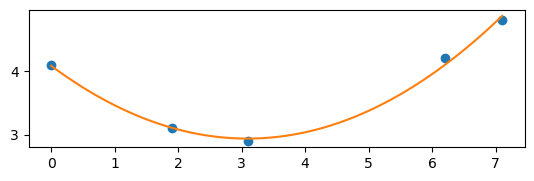

In [18]:
x = np.linspace(0, 7.1, 100)

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x_data, b, 'o')
ax.plot(x, x_solution[0,0]*x**2 + x_solution[1,0]*x + x_solution[2,0])

### (b)

In [19]:
x_data = np.array([-1.2, -0.7, -0.6, -0.3, 0.1, 1.5, 1.6, 1.6, 2.0, 2.2])[:, np.newaxis]
y_data = np.array([0.8, -0.8, -0.5, 1.4, -0.7, -1.5, -1.0, 1.8, -0.5, 0.4])[:, np.newaxis]
A = np.column_stack((x_data, y_data, np.ones_like(x_data)))
b = x_data**2 + y_data**2

q, r = forbedret_gram_schmidt(A)

x = np.linalg.solve(r, q.T @ b)

A = x[0,0]
B = x[1,0]
C = x[2,0]

print(f"Cirklen bliver da: {A}x + {B}y + {C} = x² + y²")

Cirklen bliver da: 1.3222972624684783x + 0.5974146827101411y + 2.164020578232152 = x² + y²


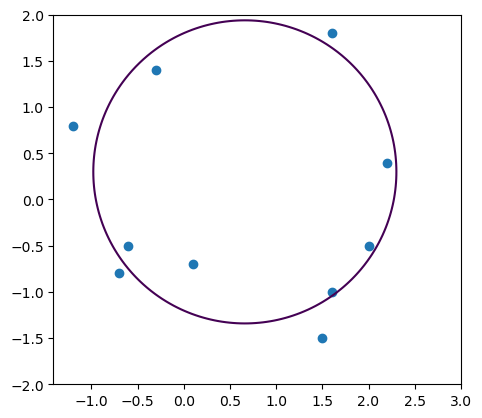

In [20]:
x = np.linspace(-1, 3, 100)
y = np.linspace(-2, 2, 100)

X, Y = np.meshgrid(x, y)
F = X**2 + Y**2 - A*X - B*Y - C

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x_data, y_data, 'o')
ax.contour(X, Y, F, [0])

## Opgave 9.2

### (a)

In [21]:
x_list = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
a = np.vander(x_list, 4)

u, s, vt = np.linalg.svd(a, full_matrices=False)
kappa_a = s[0] / s[-1]
print(kappa_a)

86.33187753066134


### (b)

In [22]:
x_list = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
a = np.vander(x_list, 4)

u, s, vt = np.linalg.svd(a, full_matrices=False)
kappa_a = s[0] / s[-1]
print(kappa_a)

1058.2220755143094


### (c)

In [23]:
x_list = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
a = np.vander(x_list, 4)

u, s, vt = np.linalg.svd(a, full_matrices=False)
kappa_a = s[0] / s[-1]
print(kappa_a)

7.103855898839082


### (d)

In [24]:
x_list = np.array([-1.0, -0.4, 0.0, 0.4, 1.0])
a = np.vander(x_list, 4)

u, s, vt = np.linalg.svd(a, full_matrices=False)
kappa_a = s[0] / s[-1]
print(kappa_a)

7.658393083687569


### (e)

In [25]:
x_list = np.array([-1.0, -0.6, 0.0, 0.6, 1.0])
a = np.vander(x_list, 4)

u, s, vt = np.linalg.svd(a, full_matrices=False)
kappa_a = s[0] / s[-1]
print(kappa_a)

7.28357463131422


Lineære fordelinger har mindre konditionstal.

## Opgave 9.3

### (a)

In [26]:
A = np.array([  [1, 0, 1],
                [0, 5, 2]])

# (i)
# Bruger standardvektorer, men kan også bruge de to første søjler da de er ortogonale
SA = np.array([ [1, 0],
                [0, 1]])

# (ii)
u, s, vt = np.linalg.svd(A, full_matrices=False)
print(u)

[[ 0.07347291 -0.99729721]
 [ 0.99729721  0.07347291]]


### (b)

In [27]:
A = np.array([  [5, 0],
                [0, 1],
                [3, 2]])

# (i)
SA = np.array([ [1, 0],
                [0, 1],
                [0, 0]])

# (ii)
u, s, vt = np.linalg.svd(A, full_matrices=False)
print(u)

[[-0.8266759   0.49944247]
 [-0.03285637 -0.50264481]
 [-0.56171827 -0.70562413]]


## Opgave 9.4

### (a)

In [28]:
k = 101
x = np.linspace(0, k-1, 100)

c = 2
y = (x/x) * c



C:\Users\henri\AppData\Local\Temp\ipykernel_15100\2800973069.py:5: RuntimeWarning: invalid value encountered in divide
  y = (x/x) * c


### (b)

## Opgave 9.5

### (a)

$$
\begin{align*}
    A^{+} & = A^{-1} \\
    V \Sigma^{-1} U^{T} & = (U \Sigma V^{T})^{-1} \\
    V \Sigma^{-1} U^{T} & = (V^{T})^{-1} \Sigma^{-1} U^{-1} \\
    V \Sigma^{-1} U^{T} & = V \Sigma^{-1} U^{T} \\
\end{align*}
$$

### (b)

#### (i)

$$
\begin{align*}
    A A^{+} A & = A \\
    (U \Sigma V^{T}) (V \Sigma^{-1} U^{T}) (U \Sigma V^{T}) & = U \Sigma V^{T} \\
    U \Sigma (V^{T} V) \Sigma^{-1} (U^{T} U) \Sigma V^{T} & = U \Sigma V^{T} \\
    U \Sigma I_{n} \Sigma^{-1} I_{n} \Sigma V^{T} & = U \Sigma V^{T} \\
    U (\Sigma \Sigma^{-1}) \Sigma V^{T} & = U \Sigma V^{T} \\
    U I_{n} \Sigma V^{T} & = U \Sigma V^{T} \\
    U \Sigma V^{T} & = U \Sigma V^{T} \\
\end{align*}
$$

#### (ii)

$$
\begin{align*}
    A^{+} A A^{+} & = A^{+} \\
    (V \Sigma^{-1} U^{T}) (U \Sigma V^{T}) (V \Sigma^{-1} U^{T}) & = V \Sigma^{-1} U^{T} \\
    V \Sigma^{-1} (U^{T} U) \Sigma (V^{T} V) \Sigma^{-1} U^{T} & = V \Sigma^{-1} U^{T} \\
    V \Sigma^{-1} I_{n} \Sigma I_{n} \Sigma^{-1} U^{T} & = V \Sigma^{-1} U^{T} \\
    V (\Sigma^{-1} \Sigma) \Sigma^{-1} U^{T} & = V \Sigma^{-1} U^{T} \\
    V I_{n} \Sigma^{-1} U^{T} & = V \Sigma^{-1} U^{T} \\
    V \Sigma^{-1} U^{T} & = V \Sigma^{-1} U^{T} \\
\end{align*}
$$

#### (iii)

$$
\begin{align*}
    (A A^{+})^{T} & = A A^{+} \\
    ((U \Sigma V^{T}) (V \Sigma^{-1} U^{T}))^{T} & = (U \Sigma V^{T}) (V \Sigma^{-1} U^{T}) \\
    (U \Sigma (V^{T} V) \Sigma^{-1} U^{T})^{T} & = U \Sigma (V^{T} V) \Sigma^{-1} U^{T} \\
    (U \Sigma I_{n} \Sigma^{-1} U^{T})^{T} & = U \Sigma I_{n} \Sigma^{-1} U^{T} \\
    (U (\Sigma \Sigma^{-1}) U^{T})^{T} & = U (\Sigma \Sigma^{-1}) U^{T} \\
    (U I_{n} U^{T})^{T} & = U I_{n} U^{T} \\
    (U U^{T})^{T} & = U U^{T} \\
    U U^{T} & = U U^{T} \\
\end{align*}
$$

#### (iv)

$$
\begin{align*}
    (A^{+} A)^{T} & = A^{+} A \\
    ((V \Sigma^{-1} U^{T}) (U \Sigma V^{T}))^{T} & = (V \Sigma^{-1} U^{T}) (U \Sigma V^{T}) \\
    (V \Sigma^{-1} (U^{T} U) \Sigma V^{T})^{T} & = V \Sigma^{-1} (U^{T} U) \Sigma V^{T} \\
    (V \Sigma^{-1} I_{n} \Sigma V^{T})^{T} & = V \Sigma^{-1} I_{n} \Sigma V^{T} \\
    (V (\Sigma^{-1} \Sigma) V^{T})^{T} & = V (\Sigma^{-1} \Sigma) V^{T} \\
    (V I_{n} V^{T})^{T} & = V I_{n} V^{T} \\
    (V V^{T})^{T} & = V V^{T} \\
    V V^{T} & = V V^{T} \\
\end{align*}
$$